# P2 : Linear Models

In [1]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

X, y = make_classification(n_samples=200, n_features=2, n_classes=2,
                           n_clusters_per_class=1, n_informative=2, n_redundant=0,
                           random_state=2021)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

X shape : (200, 2)
y shape : (200,)


In [2]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=1, n_targets=1,
                       n_informative=1, noise=200, random_state=632)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

X shape : (200, 1)
y shape : (200,)


# PLA
과제물 9페이지 참고

In [45]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=200, n_features=2, n_classes=2,
                           n_clusters_per_class=1, n_informative=2, n_redundant=0,
                           random_state=2021)

X_train = np.append(np.ones((X.shape[0], 1)), X, axis=1)
#이게 뭐냐면, 한 열을 전부 1로 맞춰서 X에다가 끼워넣는거임.
#이렇게 하면 뭐갸 좋냐? bias인거지. ㄱ나니? 바이어스=입력이 항상1인 가중치인거
y_train = np.array([[1] if label == 1 else [-1] for label in y])
w = np.array([[np.random.uniform(-1, 1)] for _ in range(X_train.shape[1])])

print(f"X_train : {X_train.shape}, w : {w.shape} #(가중치 3개에 1개는 편향)")
print(f"Xw : {np.dot(X_train, w).shape}")

max_iter = 200
for _ in range(max_iter):
    y_hat = np.sign(np.dot(X_train, w)) #시그널에 부호를 취함(선형분류)
    #print(np.sign(np.dot(X_train, w)))
    #print(y_train)


    false_idxs = np.where((y_hat != y_train))[0]
    #예측결과가 틀린 부분을 찾아서
    false_idxs = np.random.permutation(false_idxs)
    #그거 순서를 전부 뒤섞어버림

    #print(f"false_indexes : {false_idxs.shape}")
    #print(f"y : {y.shape}, X_train : {X_train.shape}")
    #print(f"weight{w.shape} + y_train{y_train.shape} * x{X_train.shape}")
    #break

    #print(X_train[idx, :])

    if false_idxs.shape[0] > 0: #아직 더 학습할게 있으면,
        #pass 야 어렵다. 좋다. 이거지. 이게 공부지. 이게 인간학습이야
        """
        for idx in false_idxs:
            #print(w.shape, (y_train[idx, 0] * X_train[idx, :]).shape)
            w = w + (y_train[idx, 0] * X_train[idx, :])[:,np.newaxis]
        """

        #포문으로 멈추지마, np이용할수 있을거야.
        #별거 아니지 ㅋㅋ -> 어렵네.
        # HELL YEAH 이거거덩~~~~ 아니아니 you 당장~
        w = w + np.sum(y_train[false_idxs] * X_train[false_idxs], axis = 0)[:, np.newaxis]
    else:
        break
    #break

print(f"y_train : {y_train.shape}, y_hat : {y_hat.shape}")

print(f"accuracy : {accuracy_score(y_train, y_hat):.2f}")

X_train : (200, 3), w : (3, 1) #(가중치 3개에 1개는 편향)
Xw : (200, 1)
y_train : (200, 1), y_hat : (200, 1)
accuracy : 0.90


In [29]:
#문법 테스팅
try:
    a = [1, 2, 3, 4, 5]
    print(a[[0, 1]])
except:
    print("파이썬 기본으로는 안돼")

try:
    b = np.array([1, 2, 3, 4, 5])
    print(b[[0, 1]])
except:
    print("넘파이도 안돼")

파이썬 기본으로는 안돼
[1 2]


In [28]:
#조건 만족하면 살리고 아니면 어쩌고
c = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
print([n if n >= 5 else -1 for n in c]) # 이런게 되네...
print(np.where(c >= 5, c, -1)) # 동일하다 하지만 넘파이 연산

[-1, -1, -1, -1, -1, np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
[-1 -1 -1 -1 -1  5  6  7  8  9]


# Pocket Algorithm
과제물 11페이지 참고

In [54]:
w = np.array([[np.random.uniform(-1, 1)] for _ in range(X_train.shape[1])])
E_in_best = y_train.shape[0]

max_iter = 200
for _ in range(max_iter):
    y_hat = np.sign(np.dot(X_train, w))

    false_idxs = np.where((y_hat != y_train))[0]
    false_idxs = np.random.permutation(false_idxs)
    if false_idxs.shape[0] > 0:
        temp_w = (w + np.sum(y_train[false_idxs] * X_train[false_idxs], axis=0)[:, np.newaxis])
        temp_E = np.sum(y_train != np.sign(np.dot(X_train, temp_w)))
        if temp_E < E_in_best:
            E_in_best = temp_E
            w = temp_w
        

    else:
        break
print(f"accuracy : {accuracy_score(y_train, y_hat):.2f}")

accuracy : 0.90


In [53]:
test_a = np.array([1, 2 ,3 , 4, 5])
test_b = np.array([0, 3, 4, 1, 2])

np.sum(test_a > test_b)

np.int64(3)

# Linear Regression Algorithm
과제물 14페이지 참고

X : (200, 1), X_train : (200, 2), y : (200,)
X_dagger (2, 200)


(np.float64(-2.2058981568340443),
 np.float64(3.2824515008800508),
 np.float64(-711.4964110721769),
 np.float64(617.433054185947))

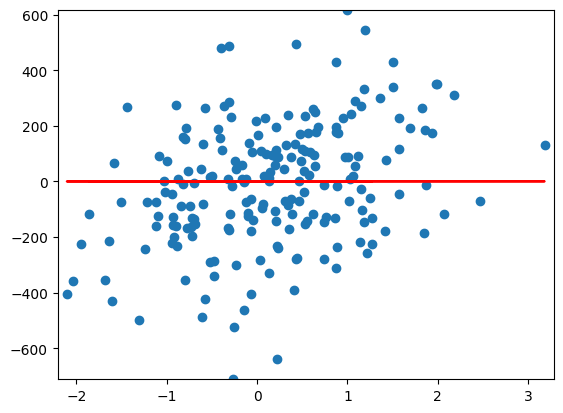

In [62]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
%matplotlib inline
X, y = make_regression(n_samples=200, n_features=1, n_targets=1,
                       n_informative=1, noise=200, random_state=9876)
X_train = np.append(np.ones((X.shape[0], 1)), X, axis=1)
print(f"X : {X.shape}, X_train : {X_train.shape}, y : {y.shape}")



X_dagger = np.dot(np.linalg.inv(np.dot(X_train.transpose(), X_train)),
                  X_train.transpose())
w_sol = np.dot(X_dagger, y_train)

print(f"X_dagger {X_dagger.shape}")

g = lambda X: np.dot(X, w_sol)

y_hat = g(X_train)

plt.scatter(X, y)
plt.plot(X, y_hat, 'red')
plt.axis([np.min(X)-.1, np.max(X)+.1, np.min(y)-.1, np.max(y)+.1])

# Logistic Regression : GD
과제 17페이지

In [63]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

def sigmoid(s):
    return 1 / (1 + np.exp(-s))

def loss(y, h):
    pass

def gradient(X, y, w):
    pass